# ETL pipelines that survive Tuesday — the hands-on half

The practical companion to **`etl_slides.html`**. The point of this session is not "read a CSV,
write a table". It is the four things that decide whether your pipeline still works in six
months: **idempotency, incrementality, validation, and recovery**.

| Part | Deck slides | What you do |
|---|---|---|
| 0 · Setup | 11 | install, sandbox, a source that behaves like a real one |
| 1 · E, T, L | 12–13 | extract → transform → load into SQLite with SQLAlchemy |
| 2 · Idempotency | 13 | run it twice; prove the table does not double |
| 3 · Incremental | 14–15 | a watermark, so run #2 moves 40 rows and not 5,000 |
| 4 · Validation | 16–17 | reject a bad batch **before** it reaches the table |
| 5 · Failure | 18–19 | retries, partial loads, a run log you can debug from |

**The problem this solves:** the first version of every pipeline works. It is the second run,
the one with duplicate rows, a changed schema and a half-finished load, that teaches you what
the job actually was.

Everything runs in a throwaway `etl_demo/` folder; the last cell deletes it.

## Step 0.1 · Install

SQLAlchemy plus pandas. SQLite ships with Python, so there is no database to run.

In [1]:
!pip install -q sqlalchemy pandas numpy matplotlib

Now the tools. **SQLAlchemy** talks to the database for you: you describe tables in Python and
it writes the SQL. The database here is **SQLite** — a whole database in a single file, so
nothing needs installing or starting.

In [2]:
%matplotlib inline
import sqlalchemy, pandas as pd, numpy as np
print("sqlalchemy", sqlalchemy.__version__)
print("pandas    ", pd.__version__)

sqlalchemy 2.0.44
pandas     2.2.3


/home/shamaseen/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/shamaseen/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## Step 0.2 · A sandbox to work in

In [3]:
import os, shutil, pathlib

BASE = pathlib.Path.cwd()          # the folder this notebook lives in
PROJ = BASE / "etl_demo"           # a throwaway sandbox, deleted by the last cell

if PROJ.exists():
    shutil.rmtree(PROJ)            # re-running this notebook is always safe
PROJ.mkdir(parents=True)
os.chdir(PROJ)
print("working inside:", os.getcwd())

working inside: /home/shamaseen/Desktop/Shai/qafza/free_Training/qafza-free-traning/05-etl/etl_demo


## Step 0.3 · A source that behaves like a real one

Real sources are not clean. This generator gives us, on purpose:

* rows that arrive **late** (an event from yesterday shows up today)
* **duplicate** event ids, because the upstream system retries
* **missing** values and a few impossible ones
* a timestamp we can use as a **watermark**

In [4]:
import os
from datetime import datetime, timedelta

rng = np.random.default_rng(7)
START = datetime(2026, 3, 1)

def make_batch(day: int, n: int = 500, dupes: int = 12, late: int = 20) -> pd.DataFrame:
    """One day's export from an upstream system, warts and all."""
    base = START + timedelta(days=day)
    ids = np.arange(day * 1000, day * 1000 + n)
    df = pd.DataFrame({
        "event_id":    ids,
        "customer_id": rng.integers(1, 900, n),
        "amount":      rng.normal(60, 25, n).round(2),
        "currency":    rng.choice(["USD", "EUR", "usd"], n, p=[.7, .2, .1]),   # messy case
        "occurred_at": [base + timedelta(minutes=int(m)) for m in rng.integers(0, 1440, n)],
    })
    df.loc[rng.random(n) < .04, "amount"] = np.nan          # holes
    df.loc[rng.random(n) < .01, "amount"] = -1.0            # impossible
    if dupes:                                               # upstream retried
        df = pd.concat([df, df.sample(dupes, random_state=day)], ignore_index=True)
    if late:                                                # yesterday, arriving today
        l = make_batch(day - 1, n=late, dupes=0, late=0) if day > 0 else None
        if l is not None: df = pd.concat([df, l], ignore_index=True)
    return df.sample(frac=1, random_state=day).reset_index(drop=True)

os.makedirs("landing", exist_ok=True)
for day in range(3):
    b = make_batch(day)
    b.to_csv(f"landing/events_day{day}.csv", index=False)
    print(f"day {day}: {len(b):4} rows, {b.event_id.duplicated().sum():3} duplicate ids, "
          f"{b.amount.isna().sum():2} missing amounts")

day 0:  512 rows,  12 duplicate ids, 22 missing amounts
day 1:  532 rows,  12 duplicate ids, 28 missing amounts
day 2:  532 rows,  12 duplicate ids, 17 missing amounts


---
# Part 1 — Extract, transform, load   ·   deck slides 12–13

Three functions, kept deliberately separate. That separation is not tidiness: it is what lets
you test the transform without a database, and re-load without re-extracting.

In [5]:
%%writefile etl.py
"""A small ETL job, written so that each stage can be tested on its own."""
from __future__ import annotations

import logging
from pathlib import Path

import pandas as pd
from sqlalchemy import create_engine, text

log = logging.getLogger("etl")

SCHEMA = {"event_id": "int64", "customer_id": "int64", "amount": "float64",
          "currency": "object", "occurred_at": "datetime64[ns]"}


# ---------------------------------------------------------------- E
def extract(path: str | Path) -> pd.DataFrame:
    """Read the source. Nothing clever -- and nothing destructive."""
    df = pd.read_csv(path, parse_dates=["occurred_at"])
    log.info("extracted %d rows from %s", len(df), path)
    return df


# ---------------------------------------------------------------- T
def transform(df: pd.DataFrame) -> pd.DataFrame:
    """Pure function: same input, same output, no database, no clock, no network.

    That purity is why this is the only stage with real business logic -- it is the
    only one you can unit-test in milliseconds.
    """
    out = df.copy()
    out["currency"] = out.currency.str.upper().str.strip()          # usd -> USD
    out = out[out.amount.notna() & (out.amount >= 0)]               # drop impossible rows
    out["amount_eur"] = out.amount * out.currency.map({"USD": 0.92, "EUR": 1.0}).fillna(1.0)
    out["occurred_date"] = out.occurred_at.dt.date.astype("string")
    out = out.drop_duplicates(subset=["event_id"], keep="last")      # upstream retries
    return out[["event_id", "customer_id", "amount", "currency",
                "amount_eur", "occurred_at", "occurred_date"]]


# ---------------------------------------------------------------- L
def load(df: pd.DataFrame, engine, table: str = "events") -> int:
    """Append rows. Part 2 replaces this with something safe to run twice."""
    df.to_sql(table, engine, if_exists="append", index=False)
    log.info("loaded %d rows into %s", len(df), table)
    return len(df)

Writing etl.py


`etl.py` is now a real module, so `import etl` gives you `extract`, `transform` and `load` as
ordinary functions. `importlib.reload` picks up edits without restarting the kernel.

In [6]:
import logging, importlib, etl
logging.basicConfig(level=logging.INFO, format="%(levelname)s %(message)s", force=True)
importlib.reload(etl)

from sqlalchemy import create_engine, text
engine = create_engine("sqlite:///warehouse.db", future=True)

raw = etl.extract("landing/events_day0.csv")
clean = etl.transform(raw)
print(f"\n{len(raw)} rows in -> {len(clean)} rows out")
print(f"  dropped {len(raw) - len(clean)} (duplicates, missing and negative amounts)")
clean.head(3)

INFO extracted 512 rows from landing/events_day0.csv



512 rows in -> 471 rows out
  dropped 41 (duplicates, missing and negative amounts)


,event_id,customer_id,amount,currency,amount_eur,occurred_at,occurred_date
1,100,617,96.98,EUR,96.9800,2026-03-01 14:08:00,2026-03-01
3,46,104,82.92,USD,76.2864,2026-03-01 10:27:00,2026-03-01
4,374,391,67.81,USD,62.3852,2026-03-01 14:03:00,2026-03-01


Load it, then count the rows. Remember the number — the next cell runs the *same* file again,
and the count is the whole point.

In [7]:
etl.load(clean, engine)
with engine.connect() as c:
    print("rows in events:", c.execute(text("select count(*) from events")).scalar())

INFO loaded 471 rows into events


rows in events: 471


### Why the transform is a pure function

`transform` takes a DataFrame and returns a DataFrame. No database, no clock, no network. So:

* you can test it with three hand-written rows and no infrastructure;
* a failure is reproducible from the input alone;
* re-running it on the same input always gives the same answer, which is what Part 2 needs.

In [8]:
# the entire test suite for the business logic -- no database required
def test_currency_is_normalised():
    out = etl.transform(pd.DataFrame({"event_id":[1],"customer_id":[1],"amount":[10.0],
        "currency":[" usd "],"occurred_at":[pd.Timestamp("2026-03-01")]}))
    assert out.currency.iloc[0] == "USD"

def test_negative_amounts_are_dropped():
    out = etl.transform(pd.DataFrame({"event_id":[1,2],"customer_id":[1,1],"amount":[-5.0,5.0],
        "currency":["USD","USD"],"occurred_at":[pd.Timestamp("2026-03-01")]*2}))
    assert list(out.event_id) == [2]

def test_duplicate_ids_collapse():
    out = etl.transform(pd.DataFrame({"event_id":[1,1],"customer_id":[1,1],"amount":[5.0,7.0],
        "currency":["USD","USD"],"occurred_at":[pd.Timestamp("2026-03-01")]*2}))
    assert len(out) == 1 and out.amount.iloc[0] == 7.0      # keep="last"

for t in [test_currency_is_normalised, test_negative_amounts_are_dropped, test_duplicate_ids_collapse]:
    t(); print("PASS", t.__name__)

PASS test_currency_is_normalised
PASS test_negative_amounts_are_dropped
PASS test_duplicate_ids_collapse


---
# Part 2 — Idempotency   ·   deck slides 13

**Idempotent** means: running it twice leaves the same result as running it once.

This is the single most valuable property an ETL job can have, because things *will* be re-run —
a retry, a backfill, someone clicking the button twice, an airflow task that timed out after it
already succeeded.

Watch the naive `append` fail that test.

In [9]:
etl.load(clean, engine)                      # exactly the same batch, a second time
with engine.connect() as c:
    n = c.execute(text("select count(*) from events")).scalar()
    dupes = c.execute(text("""select count(*) from (
                                select event_id from events group by event_id having count(*) > 1)""")).scalar()
print(f"rows now: {n}   duplicated event_ids: {dupes}")
print("\nThe same file loaded twice doubled the table. This is the bug you find in a report.")

INFO loaded 471 rows into events


rows now: 942   duplicated event_ids: 471

The same file loaded twice doubled the table. This is the bug you find in a report.


## Step 2.1 · A primary key and an upsert

Two changes make it idempotent:

1. a **primary key** on `event_id`, so the database itself refuses a duplicate;
2. an **upsert** — insert, or update the row that is already there.

SQLite and Postgres both spell it `ON CONFLICT`; SQLAlchemy gives you a dialect-specific helper.

In [10]:
from sqlalchemy import (Column, DateTime, Float, Integer, MetaData, String, Table, create_engine)
from sqlalchemy.dialects.sqlite import insert as sqlite_insert

meta = MetaData()
events = Table("events_v2", meta,
    Column("event_id",      Integer, primary_key=True),          # <- the whole trick
    Column("customer_id",   Integer, nullable=False),
    Column("amount",        Float),
    Column("currency",      String(3)),
    Column("amount_eur",    Float),
    Column("occurred_at",   DateTime),
    Column("occurred_date", String(10)),
    Column("loaded_at",     DateTime),
)
meta.create_all(engine)


def upsert(df: pd.DataFrame, engine, table=events) -> int:
    """Idempotent load: insert new rows, refresh rows we have seen before."""
    if df.empty:
        return 0
    rows = df.assign(loaded_at=pd.Timestamp.utcnow().tz_localize(None)).to_dict("records")
    stmt = sqlite_insert(table).values(rows)
    stmt = stmt.on_conflict_do_update(
        index_elements=["event_id"],
        set_={c: stmt.excluded[c] for c in df.columns if c != "event_id"})
    with engine.begin() as conn:                # one transaction: all of it, or none of it
        conn.execute(stmt)
    return len(rows)


print("first  load:", upsert(clean, engine), "rows offered")
with engine.connect() as c:
    print("  table now:", c.execute(text("select count(*) from events_v2")).scalar())
print("second load:", upsert(clean, engine), "rows offered")
with engine.connect() as c:
    print("  table now:", c.execute(text("select count(*) from events_v2")).scalar(),
          " <- unchanged. The job is idempotent.")

first  load: 471 rows offered
  table now: 471
second load: 471 rows offered
  table now: 471  <- unchanged. The job is idempotent.


Two counts, side by side: the append-only table against the upsert table, after loading the same
file twice. **Upsert** = update the row if its key is already there, insert it if not.

In [11]:
with engine.connect() as c:
    a = c.execute(text("select count(*) from events")).scalar()
    b = c.execute(text("select count(*) from events_v2")).scalar()
print(f"append-only table after two runs : {a}")
print(f"upsert table after two runs      : {b}")
assert b < a, "the upsert table must not have doubled"

append-only table after two runs : 942
upsert table after two runs      : 471


---
# Part 3 — Incremental loads   ·   deck slides 14–15

Reprocessing everything every night works until the table is large, and then it quietly becomes
the reason your pipeline takes four hours.

An **incremental** load asks: *what has changed since last time?* You need a **watermark** — the
high-water mark of what you have already processed — kept somewhere durable.

In [12]:
from sqlalchemy import Column, DateTime, MetaData, String, Table

wm = Table("etl_watermark", meta,
    Column("job",           String(64), primary_key=True),
    Column("last_occurred", DateTime),
    Column("updated_at",    DateTime))
meta.create_all(engine)


def get_watermark(job="events") -> pd.Timestamp:
    with engine.connect() as c:
        row = c.execute(text("select last_occurred from etl_watermark where job=:j"),
                        {"j": job}).fetchone()
    return pd.Timestamp(row[0]) if row and row[0] else pd.Timestamp("1970-01-01")


def set_watermark(ts: pd.Timestamp, job="events"):
    stmt = sqlite_insert(wm).values(job=job, last_occurred=ts.to_pydatetime(),
                                    updated_at=pd.Timestamp.utcnow().tz_localize(None))
    stmt = stmt.on_conflict_do_update(index_elements=["job"],
        set_={"last_occurred": stmt.excluded.last_occurred,
              "updated_at": stmt.excluded.updated_at})
    with engine.begin() as c:
        c.execute(stmt)


print("watermark before anything:", get_watermark())

watermark before anything: 1970-01-01 00:00:00


The incremental version. It asks the database what it loaded last time (the **watermark**), goes
back a little further than that (the **lateness window**, for rows that arrive late), and only
processes what is newer.

In [13]:
def run_incremental(path, job="events", lateness=pd.Timedelta("1D")):
    """Process only what is new -- minus a lateness window, so late arrivals are not lost."""
    hw = get_watermark(job)
    cutoff = hw - lateness              # deliberately reprocess a little; the upsert makes it free
    raw = etl.extract(path)
    clean = etl.transform(raw)
    new = clean[clean.occurred_at > cutoff]
    written = upsert(new, engine)
    if not clean.empty:
        set_watermark(max(hw, clean.occurred_at.max()), job)
    return len(clean), len(new), written


for day in range(3):
    total, selected, written = run_incremental(f"landing/events_day{day}.csv")
    with engine.connect() as c:
        n = c.execute(text("select count(*) from events_v2")).scalar()
    print(f"day {day}: file had {total:4} clean rows | {selected:4} after the watermark "
          f"| table total {n:4} | watermark {get_watermark().date()}")

INFO extracted 512 rows from landing/events_day0.csv


day 0: file had  471 clean rows |  471 after the watermark | table total  471 | watermark 2026-03-01


INFO extracted 532 rows from landing/events_day1.csv
INFO extracted 532 rows from landing/events_day2.csv


day 1: file had  485 clean rows |  485 after the watermark | table total  939 | watermark 2026-03-02
day 2: file had  494 clean rows |  494 after the watermark | table total 1415 | watermark 2026-03-03


Three days of files, one after another. Watch the watermark move and the table grow — then watch
day 2 run a second time and change nothing.

In [14]:
# run day 2 again -- a retry. It must move rows but change nothing.
before = None
with engine.connect() as c:
    before = c.execute(text("select count(*) from events_v2")).scalar()
run_incremental("landing/events_day2.csv")
with engine.connect() as c:
    after = c.execute(text("select count(*) from events_v2")).scalar()
print(f"table before retry {before}, after retry {after}")
assert before == after, "a retry must not change the table"
print("\nIdempotent + incremental: a retry is free, and late rows still land.")

INFO extracted 532 rows from landing/events_day2.csv


table before retry 1415, after retry 1415

Idempotent + incremental: a retry is free, and late rows still land.


### Why the lateness window

The watermark says "I have everything up to 3 March". But an event from 2 March can arrive on
the 4th — upstream was down, a device was offline, someone fixed a record.

Rewinding the cutoff by a day means those rows get reprocessed. Because the load is an **upsert**,
reprocessing costs a little compute and changes nothing else. Without idempotency this trick
would create duplicates, which is why the two properties belong together.

---
# Part 4 — Validate before you load   ·   deck slides 16–17

A pipeline that loads bad data is worse than one that fails, because the failure is loud and the
bad data is silent. Check at the boundary, and refuse the whole batch if it is wrong.

In [15]:
%%writefile validate.py
"""Contract checks. Cheap, boring, and they save whole days."""
from __future__ import annotations
import pandas as pd

REQUIRED = ["event_id", "customer_id", "amount", "currency", "occurred_at"]


class DataContractError(Exception):
    """Raised instead of loading a batch we do not trust."""


def validate(df: pd.DataFrame, *, max_null_amount=0.10, currencies=("USD", "EUR")) -> dict:
    problems, stats = [], {"rows": len(df)}

    missing = [c for c in REQUIRED if c not in df.columns]
    if missing:
        problems.append(f"missing columns: {missing}")           # schema drift

    if df.empty:
        problems.append("empty batch")

    if "event_id" in df:
        n_dupe = int(df.event_id.duplicated().sum())
        stats["duplicate_ids"] = n_dupe                          # tolerated: the upsert handles it

    if "amount" in df:
        null_rate = float(df.amount.isna().mean())
        stats["null_amount_rate"] = round(null_rate, 4)
        if null_rate > max_null_amount:                          # a spike means upstream broke
            problems.append(f"null amount rate {null_rate:.1%} over {max_null_amount:.0%}")

    if "currency" in df:
        unknown = sorted(set(df.currency.str.upper().str.strip()) - set(currencies))
        stats["unknown_currencies"] = unknown
        if unknown:
            problems.append(f"unknown currencies: {unknown}")

    if "occurred_at" in df:
        future = int((pd.to_datetime(df.occurred_at) > pd.Timestamp.utcnow().tz_localize(None)
                      + pd.Timedelta("1D")).sum())
        stats["future_rows"] = future
        if future:
            problems.append(f"{future} rows dated in the future")

    if problems:
        raise DataContractError("; ".join(problems))
    return stats

Writing validate.py


Validation now. `validate.py` holds the checks; a batch that fails one is refused **before** it
reaches the table, because a rejected batch is cheaper than a corrupted one.

In [16]:
import importlib, validate
importlib.reload(validate)

good = etl.extract("landing/events_day0.csv")
print("clean batch ->", validate.validate(good))

INFO extracted 512 rows from landing/events_day0.csv


clean batch -> {'rows': 512, 'duplicate_ids': 12, 'null_amount_rate': 0.043, 'unknown_currencies': [], 'future_rows': 0}


Four broken batches, each broken in a different realistic way. None of them should get in.

In [17]:
# now four batches that a real upstream will eventually send you
broken = {
    "a column disappeared":   good.drop(columns=["amount"]),
    "half the amounts null":  good.assign(amount=lambda d: d.amount.where(np.arange(len(d)) % 2 == 0)),
    "a new currency":         good.assign(currency=lambda d: d.currency.mask(np.arange(len(d)) < 5, "GBP")),
    "timestamps in the future": good.assign(occurred_at=lambda d: d.occurred_at + pd.Timedelta("400D")),
}
for name, df in broken.items():
    try:
        validate.validate(df)
        print(f"  {name:26} -> ACCEPTED (should not happen)")
    except validate.DataContractError as e:
        print(f"  {name:26} -> refused: {e}"[:112])

  a column disappeared       -> refused: missing columns: ['amount']
  half the amounts null      -> refused: null amount rate 52.0% over 10%
  a new currency             -> refused: unknown currencies: ['GBP']
  timestamps in the future   -> refused: 512 rows dated in the future


> **Fail the batch, not the row.** If 40% of amounts are suddenly null, the upstream export
> broke — loading the "good" 60% quietly corrupts every downstream average. Refuse it, alert,
> and let a human look. Row-level filtering is for *expected* messiness (the negative amounts in
> `transform`); batch-level validation is for *unexpected* change.

---
# Part 5 — When it fails   ·   deck slides 18–19

It will fail. The question is what you know afterwards.

## Step 5.1 · Transactions: all of it, or none of it

In [18]:
from sqlalchemy.exc import SQLAlchemyError

with engine.connect() as c:
    before = c.execute(text("select count(*) from events_v2")).scalar()

try:
    with engine.begin() as conn:                       # begin() = commit on success, rollback on error
        conn.execute(sqlite_insert(events).values(
            {"event_id": 999_001, "customer_id": 1, "amount": 10.0, "currency": "USD",
             "amount_eur": 9.2, "occurred_at": pd.Timestamp("2026-03-05"),
             "occurred_date": "2026-03-05", "loaded_at": pd.Timestamp.utcnow().tz_localize(None)}))
        raise RuntimeError("something exploded half way through the load")
except RuntimeError as e:
    print("caught:", e)

with engine.connect() as c:
    after = c.execute(text("select count(*) from events_v2")).scalar()
print(f"rows before {before}, after the failed load {after}")
assert before == after, "a failed transaction must leave nothing behind"
print("Nothing was left behind -- no half-finished batch to clean up by hand.")

caught: something exploded half way through the load
rows before 1415, after the failed load 1415
Nothing was left behind -- no half-finished batch to clean up by hand.


## Step 5.2 · Retry the things that are worth retrying

In [19]:
import time, random

def with_retry(fn, attempts=4, base=0.2, retry_on=(ConnectionError, TimeoutError)):
    """Exponential backoff with jitter. Retry transient faults only -- never a DataContractError."""
    for i in range(1, attempts + 1):
        try:
            return fn()
        except retry_on as e:
            if i == attempts:
                raise
            wait = base * 2 ** (i - 1) * (1 + random.random() * .3)
            print(f"  attempt {i} failed ({type(e).__name__}), retrying in {wait:.2f}s")
            time.sleep(wait)

calls = {"n": 0}
def flaky_source():
    calls["n"] += 1
    if calls["n"] < 3:
        raise ConnectionError("upstream refused the connection")
    return "payload"

print("result:", with_retry(flaky_source), f"after {calls['n']} attempts")
print("\nRetry a refused connection. NEVER retry a validation failure -- it will fail identically.")

  attempt 1 failed (ConnectionError), retrying in 0.21s
  attempt 2 failed (ConnectionError), retrying in 0.48s
result: payload after 3 attempts

Retry a refused connection. NEVER retry a validation failure -- it will fail identically.


## Step 5.3 · A run log, so you can answer questions later

In [20]:
runs = Table("etl_runs", meta,
    Column("run_id",     String(36), primary_key=True),
    Column("job",        String(64)),
    Column("source",     String(255)),
    Column("started_at", DateTime),
    Column("ended_at",   DateTime),
    Column("status",     String(16)),
    Column("rows_in",    Integer),
    Column("rows_out",   Integer),
    Column("message",    String(500)))
meta.create_all(engine)

import uuid, datetime as dt

def run_job(path, job="events"):
    run_id, t0 = str(uuid.uuid4()), dt.datetime.utcnow()
    rows_in = rows_out = 0
    try:
        raw = etl.extract(path); rows_in = len(raw)
        validate.validate(raw)
        total, selected, rows_out = run_incremental(path, job)
        status, msg = "success", ""
    except validate.DataContractError as e:
        status, msg = "rejected", str(e)[:500]
    except Exception as e:
        status, msg = "failed", f"{type(e).__name__}: {e}"[:500]
    with engine.begin() as c:
        c.execute(runs.insert().values(run_id=run_id, job=job, source=str(path),
            started_at=t0, ended_at=dt.datetime.utcnow(), status=status,
            rows_in=rows_in, rows_out=rows_out, message=msg))
    return status, msg

print(run_job("landing/events_day1.csv"))
bad = good.assign(currency="GBP"); bad.to_csv("landing/broken.csv", index=False)
print(run_job("landing/broken.csv"))

INFO extracted 532 rows from landing/events_day1.csv
INFO extracted 532 rows from landing/events_day1.csv
INFO extracted 512 rows from landing/broken.csv


('success', '')
('rejected', "unknown currencies: ['GBP']")


Every run wrote a row to a log table. This is what you read at 8am when someone asks why the
numbers moved.

In [21]:
log_df = pd.read_sql("select job, source, status, rows_in, rows_out, message from etl_runs", engine)
log_df["source"] = log_df.source.str.replace("landing/", "", regex=False)
log_df["message"] = log_df.message.str.slice(0, 44)
print(log_df.to_string(index=False))
print("\nThis table is what you read at 8am when someone asks why the numbers moved.")

   job          source   status  rows_in  rows_out                     message
events events_day1.csv  success      532         0                            
events      broken.csv rejected      512         0 unknown currencies: ['GBP']

This table is what you read at 8am when someone asks why the numbers moved.


Two charts from that log: how many rows each run moved, and how long each took.

INFO Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


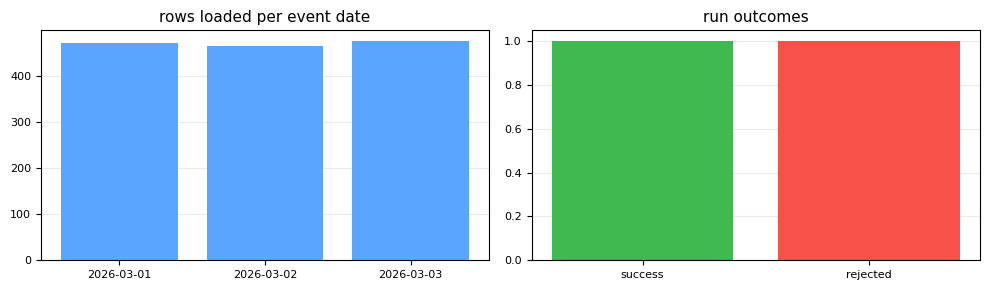

In [22]:
import matplotlib.pyplot as plt
with engine.connect() as c:
    per_day = pd.read_sql("select occurred_date, count(*) n, round(sum(amount_eur)) eur "
                          "from events_v2 group by occurred_date order by occurred_date", c)
fig, ax = plt.subplots(1, 2, figsize=(10, 3))
ax[0].bar(per_day.occurred_date, per_day.n, color="#58a6ff")
ax[0].set_title("rows loaded per event date", fontsize=11)
ax[1].bar(log_df.status.value_counts().index, log_df.status.value_counts().values,
          color=["#3fb950", "#f85149"])
ax[1].set_title("run outcomes", fontsize=11)
for a in ax: a.grid(axis="y", alpha=.25); a.set_axisbelow(True); a.tick_params(labelsize=8)
fig.tight_layout(); plt.show()

---
# Reference — worth knowing, not demonstrated here

| Topic | One-line version |
|---|---|
| Postgres instead of SQLite | change one URL: `postgresql+psycopg2://user:pw@host/db`; use `postgresql.insert` for upsert |
| ELT vs ETL | load raw first, transform in the warehouse — sensible when the warehouse is the compute |
| Orchestration | Airflow / Dagster / Prefect give you scheduling, retries and a UI; this job is the *task* they run |
| Chunked loads | `pd.read_csv(chunksize=...)` and `executemany` when a file will not fit in memory |
| Change data capture | Debezium and friends, when polling a watermark is not enough |
| Great Expectations | a full validation framework once these hand-written checks grow |
| Backfills | idempotency is what makes a backfill safe to run twice |

## Recap

| You wanted to… | Do this |
|---|---|
| test the business logic fast | keep `transform` a pure function |
| survive being run twice | primary key + `ON CONFLICT DO UPDATE` |
| stop reprocessing everything | a watermark table |
| not lose late-arriving rows | rewind the cutoff by a lateness window |
| refuse a broken batch | validate before load, raise, do not partially load |
| avoid half-finished loads | one transaction per batch (`engine.begin()`) |
| survive a flaky source | retry with backoff — transient errors only |
| answer "what happened last night" | an `etl_runs` table |

## What to do at work tomorrow

1. Run your pipeline twice on the same input. If the table changes, **fix that first** — nothing
   else matters until it is idempotent.
2. Put a primary key on the natural key and switch the load to an upsert.
3. Add a watermark table, and rewind the cutoff by more than you think you need.
4. Write five validation checks. Row count, null rate, allowed values, no future dates, schema.
5. Log every run to a table. It costs ten lines and pays for itself the first time someone asks.

## Cleanup

Everything above happened in the sandbox. This removes it.

In [23]:
import shutil, os
os.chdir(BASE)
shutil.rmtree(PROJ, ignore_errors=True)
print("sandbox removed")

sandbox removed
